In [1]:
import os, random, warnings, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

import timm
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

SEED = 42
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Устройство: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Устройство: cuda
GPU: Tesla T4


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
IMG_ZIP_PATH = '/content/drive/MyDrive/Confirmed_fronts.zip'
CSV_ZIP_PATH = '/content/drive/MyDrive/tables_V2.0.zip'
EXTRACT_ROOT = Path('/content/dvm')

print(f'Архив фото: {IMG_ZIP_PATH}')
print(f'Архив CSV : {CSV_ZIP_PATH}')

Архив фото: /content/drive/MyDrive/Confirmed_fronts.zip
Архив CSV : /content/drive/MyDrive/tables_V2.0.zip


In [4]:
def unzip(zip_path, dest):
    zip_path = Path(zip_path)
    if not zip_path.exists():
        print(f'[!] Файл не найден: {zip_path}')
        return False
    print(f'Распаковываю {zip_path.name} → {dest} ...')
    try:
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(dest)
        print('  Готово.')
        return True
    except Exception as e:
        print(f'[!] Ошибка при распаковке: {e}')
        return False

unzip(IMG_ZIP_PATH, EXTRACT_ROOT)
unzip(CSV_ZIP_PATH, EXTRACT_ROOT)

print('\nСодержимое папки:')
if EXTRACT_ROOT.exists():
    for p in sorted(EXTRACT_ROOT.iterdir()):
        print(f'  {p.name}')
else:
    print('  Папка не существует.')

Распаковываю Confirmed_fronts.zip → /content/dvm ...
  Готово.
Распаковываю tables_V2.0.zip → /content/dvm ...
  Готово.

Содержимое папки:
  Ad_table (extra).csv
  Ad_table.csv
  Basic_table.csv
  Image_table.csv
  Price_table.csv
  Sales_table.csv
  Trim_table.csv
  confirmed_fronts


In [5]:
csv_candidates = list(EXTRACT_ROOT.rglob('Image_table.csv'))

IMAGE_TABLE_PATH = csv_candidates[0]
print(f'Image_table: {IMAGE_TABLE_PATH}')

img_df = pd.read_csv(IMAGE_TABLE_PATH)
print(f'Размер: {img_df.shape}')
print(f'Колонки: {img_df.columns.tolist()}')
img_df.head(3)

Image_table: /content/dvm/Image_table.csv
Размер: (1451784, 5)
Колонки: ['Genmodel_ID', 'Image_ID', 'Image_name', 'Predicted_viewpoint', 'Quality_check']


,Genmodel_ID,Image_ID,Image_name,Predicted_viewpoint,Quality_check
0,2_1,2_1$$1$$1,Abarth$$124 Spider$$2017$$Blue$$2_1$$1$$image_...,45,NaN
1,2_1,2_1$$10$$11,Abarth$$124 Spider$$2017$$Blue$$2_1$$10$$image...,45,NaN
2,2_1,2_1$$10$$16,Abarth$$124 Spider$$2017$$Blue$$2_1$$10$$image...,0,N


In [6]:
sample_jpg = next(EXTRACT_ROOT.rglob('*.jpg'), None) or next(EXTRACT_ROOT.rglob('*.png'), None)
print(f'Пример файла: {sample_jpg}')

IMG_ROOT = sample_jpg.parents[2]
print(f'IMG_ROOT: {IMG_ROOT}')
print(f'Примеры брендов: {[p.name for p in sorted(IMG_ROOT.iterdir())[:10]]}')

Пример файла: /content/dvm/confirmed_fronts/Bentley/2015/Bentley$$Mulsanne$$2015$$Grey$$10_7$$5$$image_1.jpg
IMG_ROOT: /content/dvm/confirmed_fronts
Примеры брендов: ['Abarth', 'Alfa Romeo', 'Aston Martin', 'Audi', 'BMW', 'Bentley', 'Bugatti', 'Cadillac', 'Chevrolet', 'Chrysler']


In [7]:
print('Типы и примеры:')
print(img_df.dtypes)
print()
print(img_df.iloc[0])

Типы и примеры:
Genmodel_ID            object
Image_ID               object
Image_name             object
Predicted_viewpoint     int64
Quality_check          object
dtype: object

Genmodel_ID                                                          2_1
Image_ID                                                       2_1$$1$$1
Image_name             Abarth$$124 Spider$$2017$$Blue$$2_1$$1$$image_...
Predicted_viewpoint                                                   45
Quality_check                                                        NaN
Name: 0, dtype: object


In [18]:
split_df = img_df['Image_name'].str.split('$$', expand=True, regex=False)
print(f'Колонок после split: {split_df.shape[1]}')
print(split_df.head(2))

img_df['maker']  = split_df[0]
img_df['model']  = split_df[1]
img_df['year']   = split_df[2]
img_df['colour'] = split_df[3].str.lower().str.strip()

print(f'\nУникальных цветов: {img_df["colour"].nunique()}')
print(img_df['colour'].value_counts())

Колонок после split: 7
        0           1     2     3    4   5             6
0  Abarth  124 Spider  2017  Blue  2_1  10  image_21.jpg
1  Abarth  124 Spider  2017  Blue  2_1   4   image_0.jpg

Уникальных цветов: 23
colour
black          14317
grey            9474
white           9395
blue            8483
silver          7770
red             6095
unlisted        1516
brown            911
green            777
yellow           667
beige            600
orange           559
purple           362
bronze           329
gold             217
multicolour      196
pink              87
turquoise         26
maroon            26
burgundy           9
magenta            9
navy               1
indigo             1
Name: count, dtype: int64


In [17]:
print(img_df['Image_name'].iloc[0])
print(repr(img_df['Image_name'].iloc[0]))
print(img_df['Image_name'].iloc[0].split('$$'))

Abarth$$124 Spider$$2017$$Blue$$2_1$$10$$image_21.jpg
'Abarth$$124 Spider$$2017$$Blue$$2_1$$10$$image_21.jpg'
['Abarth', '124 Spider', '2017', 'Blue', '2_1', '10', 'image_21.jpg']


In [19]:
EXCLUDE_COLOURS = {'unlisted', 'multicolour'}
MIN_SAMPLES = 100

colour_counts = img_df['colour'].value_counts()
print('Все цвета:')
print(colour_counts.to_string())

valid_colours = colour_counts[
    (colour_counts >= MIN_SAMPLES) & (~colour_counts.index.isin(EXCLUDE_COLOURS))
].index.tolist()

df_clean = img_df[img_df['colour'].isin(valid_colours)].copy()

valid_colours_sorted = sorted(valid_colours)
CLASS2IDX   = {c: i for i, c in enumerate(valid_colours_sorted)}
IDX2CLASS   = {i: c for c, i in CLASS2IDX.items()}
NUM_CLASSES = len(valid_colours_sorted)
df_clean['label'] = df_clean['colour'].map(CLASS2IDX)

print(f'\nКлассов : {NUM_CLASSES}')
print(f'Итого   : {len(df_clean):,} изображений')
print(f'Классы  : {valid_colours_sorted}')

colour_counts_clean = df_clean['colour'].value_counts()
print(f'\nМин: {colour_counts_clean.min():,} ({colour_counts_clean.idxmin()})')
print(f'Макс: {colour_counts_clean.max():,} ({colour_counts_clean.idxmax()})')
print(f'Дисбаланс: {colour_counts_clean.max()/colour_counts_clean.min():.1f}x')

Все цвета:
colour
black          14317
grey            9474
white           9395
blue            8483
silver          7770
red             6095
unlisted        1516
brown            911
green            777
yellow           667
beige            600
orange           559
purple           362
bronze           329
gold             217
multicolour      196
pink              87
turquoise         26
maroon            26
burgundy           9
magenta            9
navy               1
indigo             1

Классов : 14
Итого   : 59,956 изображений
Классы  : ['beige', 'black', 'blue', 'bronze', 'brown', 'gold', 'green', 'grey', 'orange', 'purple', 'red', 'silver', 'white', 'yellow']

Мин: 217 (gold)
Макс: 14,317 (black)
Дисбаланс: 66.0x


In [20]:
df_trainval, df_test = train_test_split(
    df_clean, test_size=0.15, stratify=df_clean['label'], random_state=SEED
)
df_train, df_val = train_test_split(
    df_trainval, test_size=0.176, stratify=df_trainval['label'], random_state=SEED
)
print(f'Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}')

from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=df_train['label'].values
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
print(f'\nВеса классов (min/max): {class_weights.min():.3f} / {class_weights.max():.3f}')
print({IDX2CLASS[i]: f'{w:.2f}' for i, w in enumerate(class_weights)})

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.1)

Train: 41,992 | Val: 8,970 | Test: 8,994

Веса классов (min/max): 0.299 / 19.733
{'beige': '7.14', 'black': '0.30', 'blue': '0.50', 'bronze': '12.98', 'brown': '4.70', 'gold': '19.73', 'green': '5.51', 'grey': '0.45', 'orange': '7.67', 'purple': '11.81', 'red': '0.70', 'silver': '0.55', 'white': '0.46', 'yellow': '6.42'}


In [21]:
class DVMDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['full_path']).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, int(row['label'])


IMG_SIZE      = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=8),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15, hue=0.03),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

BATCH_SIZE  = 64
NUM_WORKERS = 2

train_dataset = DVMDataset(df_train, train_transform)
val_dataset   = DVMDataset(df_val,   val_transform)
test_dataset  = DVMDataset(df_test,  val_transform)

train_loader = DataLoader(train_dataset, BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train: {len(train_loader)} batches | Val: {len(val_loader)} | Test: {len(test_loader)}')

imgs, labels = next(iter(train_loader))
print(f'Батч: images {imgs.shape}, labels {labels.shape}')
print(f'Классы в батче: {sorted(labels.unique().tolist())}')

Train: 657 batches | Val: 141 | Test: 141
Батч: images torch.Size([64, 3, 224, 224]), labels torch.Size([64])
Классы в батче: [0, 1, 2, 6, 7, 8, 10, 11, 12, 13]


In [22]:
def train_one_epoch(model, loader, criterion, optimizer, device, scaler=None):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in tqdm(loader, desc='Train', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        if scaler:
            with torch.cuda.amp.autocast():
                out = model(imgs); loss = criterion(out, labels)
            scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        else:
            out = model(imgs); loss = criterion(out, labels)
            loss.backward(); optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for imgs, labels in tqdm(loader, desc='Eval', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        out  = model(imgs); loss = criterion(out, labels)
        total_loss += loss.item() * imgs.size(0)
        preds = out.argmax(1)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return total_loss / total, correct / total, f1, all_preds, all_labels


def train_model(model, name, train_loader, val_loader,
                optimizer, scheduler, criterion, device,
                num_epochs=15, patience=5):
    history = {k: [] for k in ['train_loss','val_loss','train_acc','val_acc','val_f1']}
    best_f1, best_w, p_cnt = 0.0, None, 0
    scaler = torch.cuda.amp.GradScaler() if device.type == 'cuda' else None
    print(f'\n{"="*55}\n{name}\n{"="*55}')
    for epoch in range(1, num_epochs + 1):
        tl, ta = train_one_epoch(model, train_loader, criterion, optimizer, device, scaler)
        vl, va, vf, _, _ = evaluate(model, val_loader, criterion, device)
        if scheduler:
            scheduler.step(vf) if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau) \
            else scheduler.step()
        for k, v in zip(history, [tl, vl, ta, va, vf]):
            history[k].append(v)
        print(f'Ep {epoch:2d}/{num_epochs} | '
              f'Train loss={tl:.4f} acc={ta:.3f} | '
              f'Val loss={vl:.4f} acc={va:.3f} F1={vf:.4f}', end='')
        if vf > best_f1:
            best_f1 = vf
            best_w  = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            p_cnt   = 0
            print(' ✓')
        else:
            p_cnt += 1
            print(f' ({p_cnt}/{patience})')
            if p_cnt >= patience: print('Early stop.'); break
    if best_w: model.load_state_dict(best_w)
    print(f'Лучший Val F1: {best_f1:.4f}')
    return history, best_f1


def plot_history(h, name):
    fig, ax = plt.subplots(1, 3, figsize=(16, 4))
    ep = range(1, len(h['train_loss']) + 1)
    ax[0].plot(ep, h['train_loss'], label='Train'); ax[0].plot(ep, h['val_loss'], label='Val')
    ax[0].set_title('Loss'); ax[0].legend(); ax[0].set_xlabel('Epoch')
    ax[1].plot(ep, h['train_acc'], label='Train'); ax[1].plot(ep, h['val_acc'], label='Val')
    ax[1].set_title('Accuracy'); ax[1].legend(); ax[1].set_xlabel('Epoch')
    ax[2].plot(ep, h['val_f1'], color='green', label='Val F1-macro')
    ax[2].set_title('F1-macro (Val)'); ax[2].legend(); ax[2].set_xlabel('Epoch')
    plt.suptitle(f'Кривые обучения — {name}', fontsize=13)
    plt.tight_layout(); plt.show()

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 136MB/s]


Обучаемых параметров: 1,056,270

ResNet50 — Фаза 1 (frozen)


Train:   0%|          | 0/657 [00:00<?, ?it/s]

Eval:   0%|          | 0/141 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/141 [00:00<?, ?it/s]

Ep  4/5 | Train loss=3.0325 acc=0.451 | Val loss=3.0112 acc=0.482 F1=0.4288 ✓


Train:   0%|          | 0/657 [00:00<?, ?it/s]

Eval:   0%|          | 0/141 [00:00<?, ?it/s]

Ep  5/5 | Train loss=3.0123 acc=0.463 | Val loss=3.0059 acc=0.506 F1=0.4413 ✓
Лучший Val F1: 0.4413


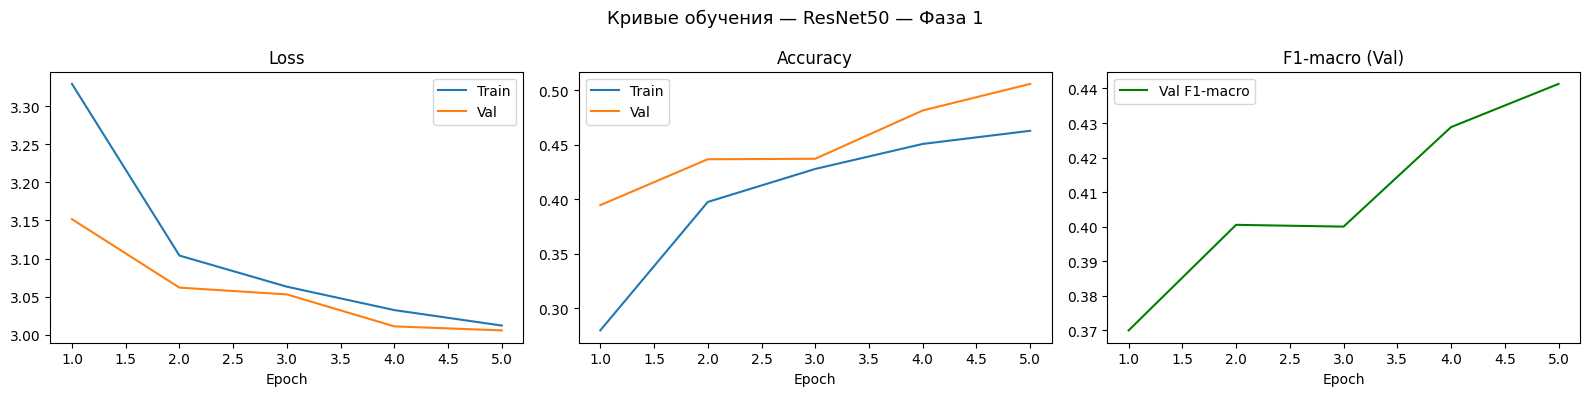

In [ ]:
set_seed()
resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
for p in resnet.parameters(): p.requires_grad = False

resnet.fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(2048, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, NUM_CLASSES)
)
resnet = resnet.to(DEVICE)

trainable = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
print(f'Обучаемых параметров: {trainable:,}')

opt1 = optim.AdamW(
    filter(lambda p: p.requires_grad, resnet.parameters()),
    lr=3e-4, weight_decay=1e-4
)
sch1 = optim.lr_scheduler.CosineAnnealingLR(opt1, T_max=5)

h_r1, _ = train_model(
    resnet, 'ResNet50 — Фаза 1 (frozen)',
    train_loader, val_loader,
    opt1, sch1, criterion, DEVICE,
    num_epochs=5, patience=3
)
plot_history(h_r1, 'ResNet50 — Фаза 1')

Обучаемых параметров: 23,119,374

ResNet50 — Фаза 2 (fine-tuning)


Train:   0%|          | 0/657 [00:00<?, ?it/s]

Eval:   0%|          | 0/141 [00:00<?, ?it/s]

Ep  1/5 | Train loss=2.9123 acc=0.538 | Val loss=2.8066 acc=0.635 F1=0.5365 ✓


Train:   0%|          | 0/657 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/141 [00:00<?, ?it/s]

Ep  4/5 | Train loss=2.6337 acc=0.699 | Val loss=2.6246 acc=0.774 F1=0.6191 ✓


Train:   0%|          | 0/657 [00:00<?, ?it/s]

Eval:   0%|          | 0/141 [00:00<?, ?it/s]

Ep  5/5 | Train loss=2.5784 acc=0.728 | Val loss=2.6179 acc=0.755 F1=0.6250 ✓
Лучший Val F1: 0.6250


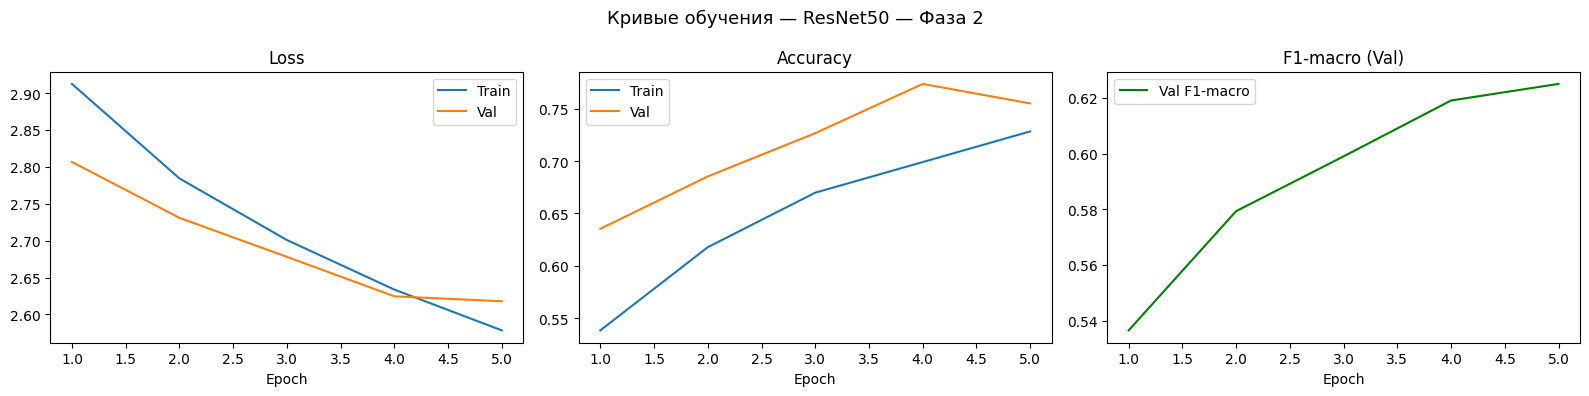

In [ ]:
for name, p in resnet.named_parameters():
    if any(name.startswith(f'layer{i}') for i in [3, 4]) or name.startswith('fc'):
        p.requires_grad = True

trainable = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
print(f'Обучаемых параметров: {trainable:,}')

opt2 = optim.AdamW([
    {'params': resnet.layer3.parameters(), 'lr': 1e-5},
    {'params': resnet.layer4.parameters(), 'lr': 2e-5},
    {'params': resnet.fc.parameters(),     'lr': 1e-4},
], weight_decay=1e-4)

sch2 = optim.lr_scheduler.ReduceLROnPlateau(opt2, mode='max', factor=0.5, patience=2)

h_r2, best_resnet_f1 = train_model(
    resnet, 'ResNet50 — Фаза 2 (fine-tuning)',
    train_loader, val_loader,
    opt2, sch2, criterion, DEVICE,
    num_epochs=5, patience=3
)
plot_history(h_r2, 'ResNet50 — Фаза 2')

model.safetensors:   0%|          | 0.00/36.8M [00:00<?, ?B/s]

EfficientNet-B2 (ImageNet-1k fallback)
Обучаемых параметров: 19,726

EfficientNet-B2 — Фаза 1 (frozen)


Train:   0%|          | 0/657 [00:00<?, ?it/s]

Eval:   0%|          | 0/141 [00:00<?, ?it/s]

Ep  1/5 | Train loss=5.8399 acc=0.109 | Val loss=4.4259 acc=0.186 F1=0.1569 ✓


...

Eval:   0%|          | 0/141 [00:00<?, ?it/s]

Ep  4/5 | Train loss=4.4904 acc=0.221 | Val loss=3.8053 acc=0.250 F1=0.2156 (1/3)


Train:   0%|          | 0/657 [00:00<?, ?it/s]

Eval:   0%|          | 0/141 [00:00<?, ?it/s]

Ep  5/5 | Train loss=4.4229 acc=0.226 | Val loss=3.7653 acc=0.258 F1=0.2251 ✓
Лучший Val F1: 0.2251


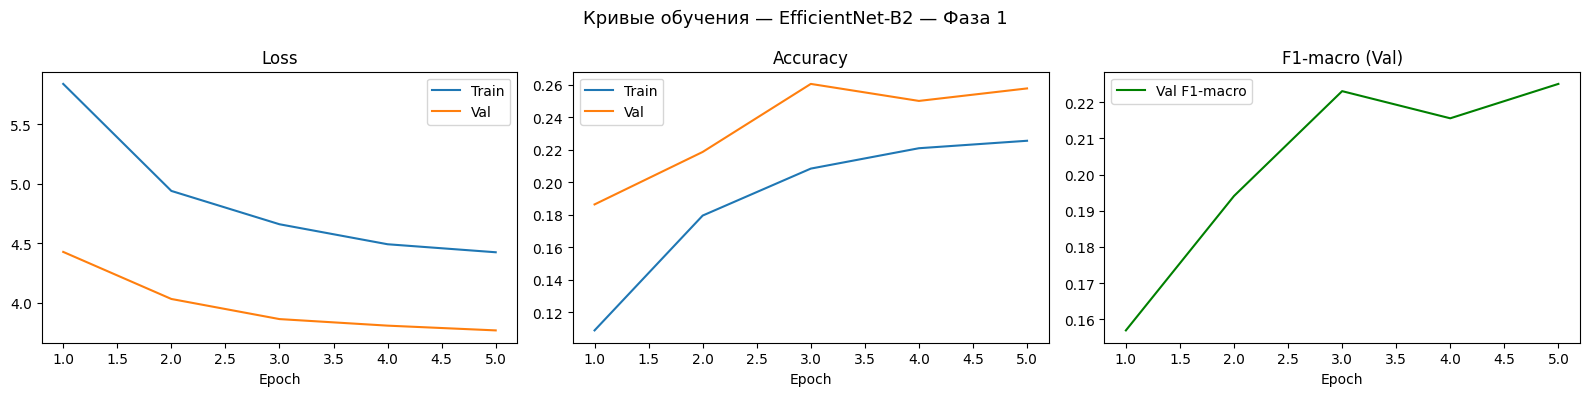

In [23]:
set_seed()
try:
    eff = timm.create_model('tf_efficientnet_b2.in21k_ft_in1k', pretrained=True,
                             num_classes=NUM_CLASSES, drop_rate=0.3, drop_path_rate=0.2)
    print('EfficientNet-B2 (ImageNet-21k)')
except Exception:
    eff = timm.create_model('efficientnet_b2', pretrained=True,
                             num_classes=NUM_CLASSES, drop_rate=0.3)
    print('EfficientNet-B2 (ImageNet-1k fallback)')
eff = eff.to(DEVICE)

for name, p in eff.named_parameters():
    if 'classifier' not in name: p.requires_grad = False

trainable = sum(p.numel() for p in eff.parameters() if p.requires_grad)
print(f'Обучаемых параметров: {trainable:,}')

opt_e1 = optim.AdamW(
    filter(lambda p: p.requires_grad, eff.parameters()),
    lr=3e-4, weight_decay=1e-4
)
sch_e1 = optim.lr_scheduler.CosineAnnealingLR(opt_e1, T_max=5)

h_e1, _ = train_model(
    eff, 'EfficientNet-B2 — Фаза 1 (frozen)',
    train_loader, val_loader,
    opt_e1, sch_e1, criterion, DEVICE,
    num_epochs=5, patience=3
)
plot_history(h_e1, 'EfficientNet-B2 — Фаза 1')


EfficientNet-B2 — Фаза 2 (fine-tuning)


Train:   0%|          | 0/657 [00:00<?, ?it/s]

Eval:   0%|          | 0/141 [00:00<?, ?it/s]

Ep  1/5 | Train loss=4.1456 acc=0.262 | Val loss=3.4403 acc=0.326 F1=0.2784 ✓


Train:   0%|          | 0/657 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/141 [00:00<?, ?it/s]

Ep  4/5 | Train loss=3.0749 acc=0.402 | Val loss=2.9202 acc=0.476 F1=0.4264 ✓


Train:   0%|          | 0/657 [00:00<?, ?it/s]

Eval:   0%|          | 0/141 [00:00<?, ?it/s]

Ep  5/5 | Train loss=2.9711 acc=0.452 | Val loss=2.8505 acc=0.501 F1=0.4478 ✓
Лучший Val F1: 0.4478


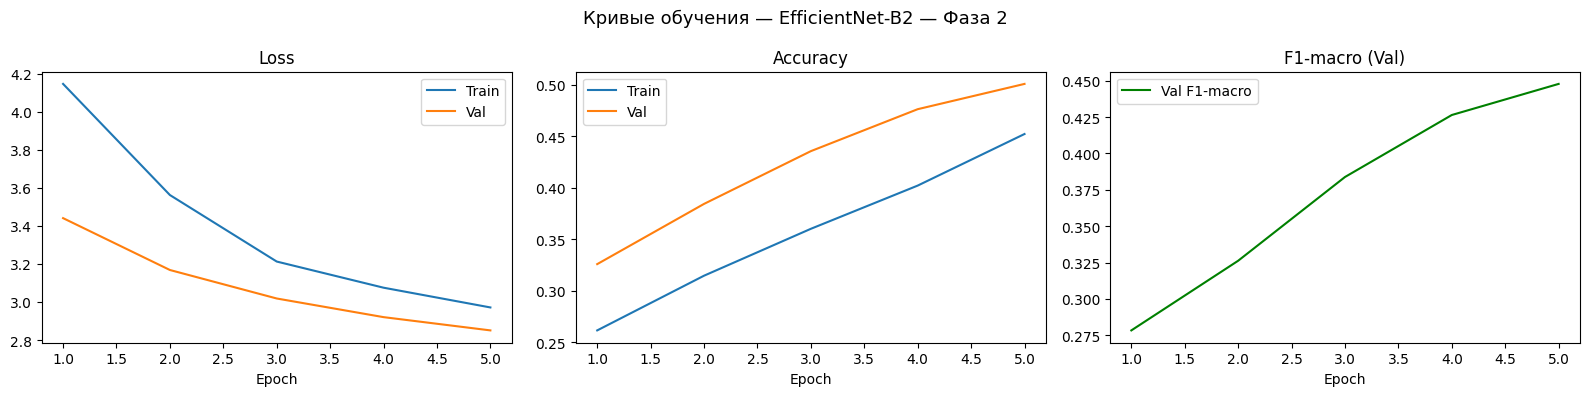

In [24]:
for p in eff.parameters(): p.requires_grad = True

blocks = list(eff.named_children()); n = max(len(blocks)-1, 1)
pg = [{'params': m.parameters(), 'lr': 5e-6 + 1.5e-5 * (i/n)}
      for i, (nm, m) in enumerate(blocks)]

opt_e2 = optim.AdamW(pg, weight_decay=1e-4)
sch_e2 = optim.lr_scheduler.ReduceLROnPlateau(opt_e2, mode='max', factor=0.5, patience=2)

h_e2, best_eff_f1 = train_model(
    eff, 'EfficientNet-B2 — Фаза 2 (fine-tuning)',
    train_loader, val_loader,
    opt_e2, sch_e2, criterion, DEVICE,
    num_epochs=5, patience=3
)
plot_history(h_e2, 'EfficientNet-B2 — Фаза 2')

In [25]:
class ChannelAttention(nn.Module):
    def __init__(self, ch, r=16):
        super().__init__()
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(ch, ch//r), nn.ReLU(),
            nn.Linear(ch//r, ch), nn.Sigmoid()
        )
    def forward(self, x): return x * self.se(x).view(x.size(0), x.size(1), 1, 1)

class ResBlock(nn.Module):
    def __init__(self, ic, oc, s=1, attn=True):
        super().__init__()
        self.c1 = nn.Conv2d(ic, oc, 3, s, 1, bias=False); self.b1 = nn.BatchNorm2d(oc)
        self.c2 = nn.Conv2d(oc, oc, 3, 1, 1, bias=False); self.b2 = nn.BatchNorm2d(oc)
        self.act = nn.GELU(); self.dp = nn.Dropout2d(0.05)
        self.at  = ChannelAttention(oc) if attn else nn.Identity()
        self.sc  = nn.Sequential(nn.Conv2d(ic,oc,1,s,bias=False), nn.BatchNorm2d(oc)) \
                   if s!=1 or ic!=oc else nn.Sequential()
    def forward(self, x):
        o = self.act(self.b1(self.c1(x))); o = self.dp(o)
        o = self.b2(self.c2(o)); o = self.at(o)
        return self.act(o + self.sc(x))

class ColorNet(nn.Module):
    def __init__(self, nc, drop=0.4):
        super().__init__()
        self.stem   = nn.Sequential(
            nn.Conv2d(3,32,7,2,3,bias=False), nn.BatchNorm2d(32), nn.GELU(), nn.MaxPool2d(3,2,1)
        )
        self.stage1 = nn.Sequential(ResBlock(32, 64, 1, False), ResBlock(64,  64))
        self.stage2 = nn.Sequential(ResBlock(64, 128, 2),       ResBlock(128, 128))
        self.stage3 = nn.Sequential(ResBlock(128,256, 2),       ResBlock(256, 256), ResBlock(256,256))
        self.stage4 = nn.Sequential(ResBlock(256,512, 2),       ResBlock(512, 512))
        self.gap = nn.AdaptiveAvgPool2d(1); self.gmp = nn.AdaptiveMaxPool2d(1)
        self.head = nn.Sequential(
            nn.Flatten(), nn.LayerNorm(1024), nn.Dropout(drop),
            nn.Linear(1024,256), nn.GELU(), nn.Dropout(drop/2), nn.Linear(256,nc)
        )
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None: nn.init.zeros_(m.bias)
    def forward(self, x):
        x = self.stem(x); x = self.stage1(x); x = self.stage2(x)
        x = self.stage3(x); x = self.stage4(x)
        return self.head(torch.cat([self.gap(x), self.gmp(x)], 1))

ColorNet параметров: 12,701,170

ColorNet (с нуля)


Train:   0%|          | 0/657 [00:00<?, ?it/s]

Eval:   0%|          | 0/141 [00:00<?, ?it/s]

Ep  1/6 | Train loss=3.6159 acc=0.077 | Val loss=3.3554 acc=0.240 F1=0.2201 ✓


Train:   0%|          | 0/657 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/141 [00:00<?, ?it/s]

Ep  5/6 | Train loss=2.9940 acc=0.513 | Val loss=2.8793 acc=0.681 F1=0.5326 ✓


Train:   0%|          | 0/657 [00:00<?, ?it/s]

Eval:   0%|          | 0/141 [00:00<?, ?it/s]

Ep  6/6 | Train loss=2.9408 acc=0.551 | Val loss=2.8368 acc=0.697 F1=0.5402 ✓
Лучший Val F1: 0.5402


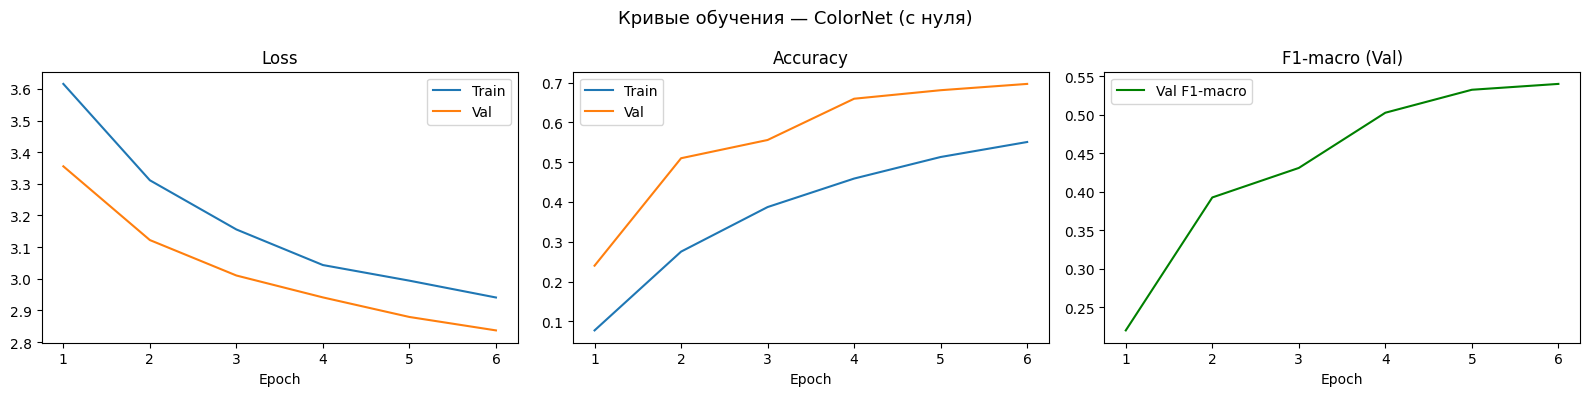

In [27]:
set_seed()
colornet = ColorNet(NUM_CLASSES).to(DEVICE)
print(f'ColorNet параметров: {sum(p.numel() for p in colornet.parameters()):,}')

opt_cn = optim.AdamW(colornet.parameters(), lr=3e-4, weight_decay=5e-4)
sch_cn = optim.lr_scheduler.OneCycleLR(
    opt_cn, max_lr=1e-3,
    steps_per_epoch=len(train_loader),
    epochs=10, pct_start=0.1, anneal_strategy='cos'
)

h_cn, best_cn_f1 = train_model(
    colornet, 'ColorNet (с нуля)',
    train_loader, val_loader,
    opt_cn, sch_cn, criterion, DEVICE,
    num_epochs=6, patience=3
)
plot_history(h_cn, 'ColorNet (с нуля)')